In [8]:
import nltk
from collections import Counter
from nltk.util import ngrams
from nltk.corpus import stopwords
import pandas as pd
import json
import re
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("../data/processed/listing_sample.csv")

In [6]:
df["remarks"].str.split().str.len().describe()

count    1000.000000
mean      179.432000
std        85.692021
min         8.000000
25%       118.000000
50%       167.000000
75%       224.000000
max       645.000000
Name: remarks, dtype: float64

<Axes: >

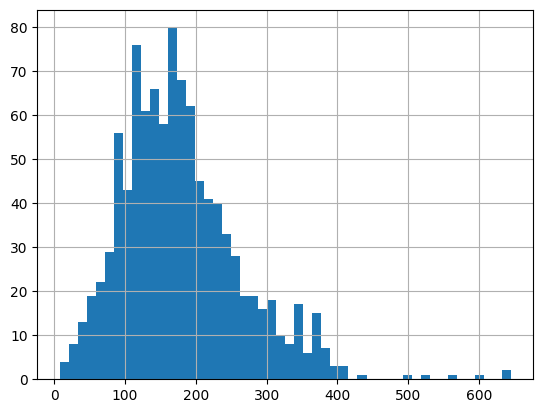

In [9]:
df["remarks"].str.split().str.len().hist(bins=50)

In [ ]:

with open("../data/processed/taxonomy.json", 'r') as f:
    data = json.load(f)
terms = set([item["term"] for item in data])
stop_words = set(stopwords.words("english"))

bigram_sizes = []
text_length = 0
term_count = 0
for text in df["remarks"]:
    tokens = [ t for t in nltk.word_tokenize(text) if re.match(r"[a-z]+", t.lower())]
    bigrams = [" ".join(bg) for bg in ngrams(tokens, 2) if bg[0] not in stop_words and bg[1] not in stop_words]
    bigram_sizes.append(len(bigrams))
    for b in bigrams:
        if b in terms:
            term_count +=1
    text_length += len(bigrams)
coverage = term_count / text_length * 100
print(term_count)
print(text_length)
print(max(bigram_sizes))
print(sum(bigram_sizes) / len(bigram_sizes))
print(coverage)

20198
63639
244
63.639
31.738399409167332
